# Monodomain PINN vs OR-OSPINN

This cleaned version keeps the original outputs and figures while making the notebook easier to present. Markdown cells explain each stage, and code cells keep only a short purpose line before the executable code.


## OSPINN: Configuration 1

This cell trains the optimized Schwarz PINN model for the first decomposition/configuration and keeps the original training output visible.


In [ ]:
# @title OSPINN training, configuration 1
# Purpose: Train the optimized Schwarz PINN model for configuration 1.

import torch, torch.nn as nn, torch.optim as optim
import copy, numpy as np, matplotlib.pyplot as plt, os, math
from math import pi
from concurrent.futures import ThreadPoolExecutor
import time
torch.manual_seed(1234); np.random.seed(1234)
torch.set_default_dtype(torch.float32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device :", device)

def _now():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.perf_counter()

os.makedirs("checkpoints", exist_ok=True)
best_ckpt = {
    "metric": float("inf"),
    "it": 0,
    "z1": None,
    "z2": None,
}
def _is_finite(x): return (x is not None) and (not math.isnan(x)) and (not math.isinf(x))
def _save(sd, path): torch.save(sd, path)

L, delta = 1.0, 0.3
Tmin, Tmax = 0.0, 1.0
dt  = 0.01
Nt  = int((Tmax - Tmin) / dt)
max_iter = 35
tol      = 1e-5
l2eps    = 1e-5
WARM_START = True

def u_exact(x,t): return -pi**2 * torch.sin(pi*x) * torch.cos(t)
def v_exact(x,t): return -           torch.sin(pi*x) * torch.sin(t)
def f_rhs (x,t): return (pi**4 - 1.0) * torch.sin(pi*x) * torch.cos(t)
def z_exact(x,t): return torch.cat([u_exact(x,t), v_exact(x,t)], 1)

def sample_xt(xa, xb, ta, tb, N):
    x = xa + (xb - xa) * torch.rand(N,1, device=device)
    t = ta + (tb - ta) * torch.rand(N,1, device=device)
    return torch.cat([x,t], 1)

def make_grad(z):
    return z.detach().clone().requires_grad_(True)

def deriv_all(out, xt):
    """Return [∂_t u, ∂_t v, ∂_x u, ∂_x v]."""
    u, v = out[:,0:1], out[:,1:2]
    gu = torch.autograd.grad(u, xt, torch.ones_like(u),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    gv = torch.autograd.grad(v, xt, torch.ones_like(v),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    if gu is None: gu = torch.zeros_like(xt)
    if gv is None: gv = torch.zeros_like(xt)
    return gu[:,1:2], gv[:,1:2], gu[:,0:1], gv[:,0:1]

def second_x(first_x, xt):
    g = torch.autograd.grad(first_x, xt, torch.ones_like(first_x),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None: g = torch.zeros_like(first_x)
    return g[:,0:1]

def build_complex_kernels(a, sign):
    ω   = 2*np.pi*np.fft.fftfreq(Nt, d=dt)
    eta = 1e-3/dt
    k   = np.sqrt(ω + 1j*eta)
    ka  = k * a

    s, c = np.sin(ka), np.cos(ka)
    s = np.where(np.abs(s)>1e-9, s, np.sign(np.real(s))*1e-9 + 0j)

    spec = sign * (k * c / s)

    spec[0] = sign * (1.0/a)
    K  = np.fft.ifft(spec) / dt
    Ka = K.real.astype(np.float32)
    Kb = K.imag.astype(np.float32)
    return torch.tensor(Ka, dtype=torch.float32, device=device), \
           torch.tensor(Kb, dtype=torch.float32, device=device)

def build_toeplitz(K):
    Nt_ = K.numel()
    W   = torch.zeros(Nt_, Nt_, device=device, dtype=K.dtype)
    for k in range(Nt_):
        W[k, :k+1] = K[:k+1].flip(0)
    return W * dt

Ka1, Kb1 = build_complex_kernels(L - delta, +1)
Ka2, Kb2 = build_complex_kernels(delta,     -1)
Wa1, Wb1 = build_toeplitz(Ka1), build_toeplitz(Kb1)
Wa2, Wb2 = build_toeplitz(Ka2), build_toeplitz(Kb2)

def interface_LHS_complex(net, xt_if_all, Wa, Wb):
    xtg  = make_grad(xt_if_all)
    out  = net(xtg)
    _, _, ux, vx = deriv_all(out, xtg)
    du   = torch.cat([ux, vx], 1)
    Ra   = (Wa @ out)
    Rb   = (Wb @ out)
    JRb  = torch.stack([-Rb[:,1], Rb[:,0]], dim=1)
    return du + Ra + JRb, out

def build_target_from_other_complex(net_other, xt_if_all, Wa, Wb):
    xtg  = xt_if_all.detach().clone().requires_grad_(True)
    out  = net_other(xtg)
    _, _, ux, vx = deriv_all(out, xtg)
    du   = torch.cat([ux, vx], 1)
    Ra   = (Wa @ out)
    Rb   = (Wb @ out)
    JRb  = torch.stack([-Rb[:,1], Rb[:,0]], dim=1)
    return (du + Ra + JRb).detach()

class Net(nn.Module):
    def __init__(self, depth=6, width=24):
        super().__init__()
        self.act = nn.Tanh()
        self.inp = nn.Linear(2, width)
        self.hid = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.out = nn.Linear(width, 2)

    def forward(self, xt):
        z = self.act(self.inp(xt))
        for lin in self.hid:
            z = self.act(lin(z))
        h = self.out(z)

        x = xt[:, 0:1]
        t = xt[:, 1:2]
        Sx = x * (1.0 - x)

        u0 = -pi**2 * torch.sin(pi * x)
        v0 = torch.zeros_like(x)

        u_hat = h[:, 0:1]
        v_hat = h[:, 1:2]

        u = u0 + Sx * t * u_hat
        v = v0 + Sx * t * v_hat

        return torch.cat([u, v], dim=1)

def init_xavier(m):
    for l in m.modules():
        if isinstance(l, nn.Linear):
            nn.init.xavier_uniform_(l.weight, gain=nn.init.calculate_gain('tanh'))
            l.bias.data.zero_()

def new_model(seed):
    torch.manual_seed(seed)
    net = Net().to(device)
    init_xavier(net)
    return net

w_pde  = 1.0
w_if   = 1.0
p_exp  = 2

Ni_int1, Ni_int2 = 100,100
xt_int1 = sample_xt(0,       delta, Tmin, Tmax, Ni_int1)
xt_int2 = sample_xt(delta,   L,     Tmin, Tmax, Ni_int2)

t_all     = torch.arange(Nt, device=device).unsqueeze(1) * dt
x_if_all  = torch.full((Nt,1), delta, device=device)
xt_if_all = torch.cat([x_if_all, t_all], 1)

z1, z2 = new_model(1), new_model(2)

def l2_errors_uv(z1, z2, delta, Nx=1000):
    x = torch.linspace(0.0, 1.0, Nx, device=device)
    t = (Tmin + torch.arange(Nt, device=device) * dt).clamp(max=Tmin + (Nt-1)*dt)
    X, Tm = torch.meshgrid(x, t, indexing='ij')

    with torch.no_grad():
        XT   = torch.stack([X.reshape(-1), Tm.reshape(-1)], dim=1)
        out1 = z1(XT)
        out2 = z2(XT)
        Z    = torch.where((XT[:, 0:1] <= delta).expand_as(out1), out1, out2)

        U = Z[:, 0].reshape(Nx, Nt)
        V = Z[:, 1].reshape(Nx, Nt)

        Ue = u_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(U.dtype)
        Ve = v_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(V.dtype)

        L2_u = torch.mean((U - Ue) ** 2).sqrt().item()
        L2_v = torch.mean((V - Ve) ** 2).sqrt().item()

    return L2_u, L2_v

@torch.no_grad()
def interface_gap_L2_time(z1, z2, delta, Nt, dt, device):
    t = torch.arange(Nt, device=device, dtype=torch.float32).unsqueeze(1) * dt
    x = torch.full((Nt, 1), float(delta), device=device, dtype=torch.float32)
    xt = torch.cat([x, t], 1)
    diff = z1(xt) - z2(xt)
    per_t = torch.linalg.norm(diff, dim=1)
    return float(torch.sqrt(torch.sum(per_t**2) * dt))

@torch.no_grad()
def plot_piecewise_at_t(
    z1_model: torch.nn.Module,
    z2_model: torch.nn.Module,
    t_value: float,
    delta: float,
    L: float = 1.0,
    n1: int = 400,
    n2: int = 400,
    comp: int = 0,
    save_path: str | None = None,
    show_gap: bool = True,
    show_fig: bool = False,
):
    """
    Plot z1 on [0,delta) and z2 on [delta,L] at fixed time t_value.
    If model output has 2 columns, 'comp' selects the component (0=u, 1=v).
    Returns a dict with the pointwise interface gap at x=delta.
    """

    def _first_param_device_dtype(m):
        p = next(m.parameters(), None)
        return (p.device, p.dtype) if p is not None else (torch.device('cpu'), torch.float32)

    dev1, dt1 = _first_param_device_dtype(z1_model)
    dev2, dt2 = _first_param_device_dtype(z2_model)
    use_dev = dev1 if dev1.type != 'cpu' else dev2
    use_dt  = dt1

    x1 = torch.linspace(0.0, float(delta), steps=max(n1, 2), device=use_dev, dtype=use_dt)
    if x1.numel() > 1: x1 = x1[:-1]
    x2 = torch.linspace(float(delta), float(L), steps=max(n2, 2), device=use_dev, dtype=use_dt)

    t1 = torch.full_like(x1, float(t_value))
    t2 = torch.full_like(x2, float(t_value))
    xt1 = torch.stack([x1, t1], dim=1)
    xt2 = torch.stack([x2, t2], dim=1)

    z1_model.eval(); z2_model.eval()
    y1 = z1_model(xt1)
    y2 = z2_model(xt2)

    def _pick_column(Y):
        if Y.ndim == 1:        return Y
        if Y.shape[1] == 1:    return Y[:, 0]
        if Y.shape[1] >= 2:    return Y[:, comp]
        raise ValueError("Unsupported model output shape.")

    y1c = _pick_column(y1)
    y2c = _pick_column(y2)

    gap_info = None
    if show_gap:
        xt_delta = torch.tensor([[float(delta), float(t_value)]], device=use_dev, dtype=use_dt)
        y1d = _pick_column(z1_model(xt_delta)).item()
        y2d = _pick_column(z2_model(xt_delta)).item()
        gap_info = dict(x=float(delta), z1=y1d, z2=y2d, gap=y1d - y2d)

    x1_np, y1_np = x1.detach().cpu().numpy(), y1c.detach().cpu().numpy()
    x2_np, y2_np = x2.detach().cpu().numpy(), y2c.detach().cpu().numpy()

    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    ax.plot(x1_np, y1_np, linewidth=1.8, label=r"$z_1(x,t_\star)$ on $[0,\delta)$")
    ax.plot(x2_np, y2_np, linewidth=1.8, label=r"$z_2(x,t_\star)$ on $[\delta,L]$")
    ax.axvline(float(delta), linestyle="--", linewidth=1.0)

    if show_gap and gap_info is not None:
        ax.scatter([gap_info["x"]], [gap_info["z1"]], s=30, zorder=3, label=r"$z_1(\delta,t_\star)$")
        ax.scatter([gap_info["x"]], [gap_info["z2"]], s=30, zorder=3, label=r"$z_2(\delta,t_\star)$")

    ax.set_xlabel("x"); ax.set_ylabel(f"component {comp}")
    ax.set_xlim(0.0, float(L)); ax.grid(True, linewidth=0.4, alpha=0.4)
    ttl_gap = "" if gap_info is None else f", gap={gap_info['gap']:.2e}"
    ax.set_title(fr"Piecewise at $t_\star={t_value}$ (comp={comp}), $\delta={delta}$" + ttl_gap)
    ax.legend(loc="best", fontsize=9, frameon=True)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=160)
    if show_fig:
        plt.show()
    plt.close(fig)

    return gap_info
def after_iter_plot(
    it: int,
    z1_model: torch.nn.Module,
    z2_model: torch.nn.Module,
    t_value: float,
    delta: float,
    outdir: str = "content/mnt/iter_plots",
    L: float = 1.0
):
    """
    Save two figures per iteration (u and v) at time t_value.
    Returns the gaps at x=delta for u and v.
    """
    os.makedirs(outdir, exist_ok=True)
    p_u = os.path.join(outdir, f"u_iter{it:03d}.png")
    p_v = os.path.join(outdir, f"v_iter{it:03d}.png")

    g_u = plot_piecewise_at_t(z1_model, z2_model, t_value, delta, L=L, comp=0, save_path=p_u, show_gap=True)
    g_v = plot_piecewise_at_t(z1_model, z2_model, t_value, delta, L=L, comp=1, save_path=p_v, show_gap=True)
    return {"gap_u": (None if g_u is None else g_u["gap"]),
            "gap_v": (None if g_v is None else g_v["gap"])}

def warm_start(net, domain='left', steps=300, lr=1e-3):
    opt = optim.Adam(net.parameters(), lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        xtg  = make_grad(xt_int1 if domain == 'left' else xt_int2)
        outg = net(xtg)
        u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
        lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
        loss = w_pde * lpde
        loss.backward(); opt.step()

def fit_Omega1(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int1)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
            lhs, _ = interface_LHS_complex(net, xt_if_all, Wa1, Wb1)
            lif = (lhs - target_full).abs().pow(p_exp).mean()
            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss
        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

def fit_Omega2(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int2)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
            lhs, _ = interface_LHS_complex(net, xt_if_all, Wa2, Wb2)
            lif = (lhs - target_full).abs().pow(p_exp).mean()
            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss
        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

def interface_metrics_complex(z1, z2, xt_if_all, Wa1, Wb1, Wa2, Wb2):
    xtg = xt_if_all.detach().clone().requires_grad_(True)
    out1, out2 = z1(xtg), z2(xtg)

    _,_,ux1,vx1 = deriv_all(out1, xtg); du1 = torch.cat([ux1, vx1], 1)
    _,_,ux2,vx2 = deriv_all(out2, xtg); du2 = torch.cat([ux2, vx2], 1)

    Ra1_1 = Wa1 @ out1; Rb1_1 = Wb1 @ out1; JRb1_1 = torch.stack([-Rb1_1[:,1], Rb1_1[:,0]], 1)
    Ra1_2 = Wa1 @ out2; Rb1_2 = Wb1 @ out2; JRb1_2 = torch.stack([-Rb1_2[:,1], Rb1_2[:,0]], 1)
    L1_z1 = du1 + Ra1_1 + JRb1_1
    L1_z2 = du2 + Ra1_2 + JRb1_2

    Ra2_2 = Wa2 @ out2; Rb2_2 = Wb2 @ out2; JRb2_2 = torch.stack([-Rb2_2[:,1], Rb2_2[:,0]], 1)
    Ra2_1 = Wa2 @ out1; Rb2_1 = Wb2 @ out1; JRb2_1 = torch.stack([-Rb2_1[:,1], Rb2_1[:,0]], 1)
    L2_z2 = du2 + Ra2_2 + JRb2_2
    L2_z1 = du1 + Ra2_1 + JRb2_1

    r1 = torch.sqrt(((L1_z1 - L1_z2)**2).mean()).item()
    r2 = torch.sqrt(((L2_z2 - L2_z1)**2).mean()).item()
    return r1, r2

t_decomp_total0 = _now()
t_warm = 0.0
iter_times = []

if WARM_START:
    t0 = _now()
    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(warm_start, z1, xt_int1, 300, 1e-3)
        f2 = pool.submit(warm_start, z2, xt_int2, 300, 1e-3)
        f1.result(); f2.result()
    t_warm = _now() - t0
    print(f"[Timing] Warm-start total (parallel): {t_warm:.3f} s")

for it in range(1, max_iter+1):
    t_it0 = _now()
    print(f"\n=== Schwarz iteration {it} (global in time, parallel Jacobi) ===")

    target_R1_full = build_target_from_other_complex(z2, xt_if_all, Wa1, Wb1)
    target_R2_full = build_target_from_other_complex(z1, xt_if_all, Wa2, Wb2)

    def _train_O1():
        fit_Omega1(z1, optim.Adam(z1.parameters(), lr=1e-3), 100, target_R1_full)
        z1.eval()
        fit_Omega1(z1, optim.LBFGS(z1.parameters(), lr=1, max_iter=20), 15, target_R1_full)
        return True
    def _train_O2():
        fit_Omega2(z2, optim.Adam(z2.parameters(), lr=1e-3), 100, target_R2_full)
        z2.eval()
        fit_Omega2(z2, optim.LBFGS(z2.parameters(), lr=1, max_iter=20), 15, target_R2_full)
        return True

    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(_train_O1)
        f2 = pool.submit(_train_O2)
        f1.result(); f2.result()
    t_it = _now() - t_it0
    iter_times.append(t_it)
    print(f"[Timing] Schwarz iter {it} : {t_it:.3f} s")

    r1, r2 = interface_metrics_complex(z1, z2, xt_if_all, Wa1, Wb1, Wa2, Wb2)
    res = max(r1, r2)
    print(f"r1={r1:.3e}  r2={r2:.3e}  (max={res:.3e})")

    L2u, L2v = l2_errors_uv(z1, z2, delta, Nx=100)
    print(f"[iter {it}] L2(u)={L2u:.3e}  L2(v)={L2v:.3e}")
    diffz = interface_gap_L2_time(z1, z2, delta, Nt, dt, device)
    print(f"[iter {it}] z1(δ,⋅)−z2(δ,⋅)(t)={diffz:.3e}")
    after_iter_plot(it, z1, z2, t_value=0.2, delta=delta, outdir="content/mnt/iter_plots", L=L)

    if max(L2u, L2v) <= l2eps or diffz <= tol:
        print("Converged (global-in-time) by tolerance.")
        break

t_decomp_total = _now() - t_decomp_total0
if iter_times:
    avg_it = sum(iter_times) / len(iter_times)
    print(f"\n[Timing] Decomposed (z1/z2) total: {t_decomp_total:.3f} s "
          f"(warm-start {t_warm:.3f} s, Schwarz {t_decomp_total - t_warm:.3f} s)")
    print(f"[Timing] Schwarz per-iter: avg {avg_it:.3f} s, "
          f"min {min(iter_times):.3f} s, max {max(iter_times):.3f} s")

print("\nFinished global-in-time Schwarz with complex DtN (Example 3).")
_save(z1.state_dict(), "checkpoints/final_last_z1.pt")
_save(z2.state_dict(), "checkpoints/final_last_z2.pt")
print("Saved final (last-iteration) models to checkpoints/final_last_*.pt")


Device : cpu
[Timing] Warm-start total (parallel): 19.148 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 15.650 s
r1=2.995e+00  r2=6.056e+00  (max=6.056e+00)
[iter 1] L2(u)=6.725e-01  L2(v)=2.317e-01
[iter 1] z1(δ,⋅)−z2(δ,⋅)(t)=5.368e-01

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 2 : 15.458 s
r1=4.896e+00  r2=1.456e+00  (max=4.896e+00)
[iter 2] L2(u)=2.528e-01  L2(v)=3.817e-01
[iter 2] z1(δ,⋅)−z2(δ,⋅)(t)=5.563e-01

=== Schwarz iteration 3 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 3 : 15.475 s
r1=1.132e+00  r2=2.483e+00  (max=2.483e+00)
[iter 3] L2(u)=1.084e-01  L2(v)=3.034e-01
[iter 3] z1(δ,⋅)−z2(δ,⋅)(t)=2.072e-01

=== Schwarz iteration 4 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 4 : 15.904 s
r1=2.076e+00  r2=5.443e-01  (max=2.076e+00)
[iter 4] L2(u)=1.051e-01  L2(v)=1.721e-01
[iter 4] z1(δ,⋅)−z2(δ,⋅)(t)=2.225e-01

=== Schwarz iteration 5 (global in time, parallel J

## Displacement Reconstruction After Configuration 1

This cell reconstructs the displacement `y` from the OSPINN fields `u` and `v` produced by configuration 1.


In [ ]:
# @title Displacement reconstruction, configuration 1
# Purpose: Train a displacement model Y using the configuration 1 OSPINN fields.

import time
BEST_Z1_CKPT = "checkpoints/final_last_z1.pt"
BEST_Z2_CKPT = "checkpoints/final_last_z2.pt"
BEST_Y_CKPT  = "/content/Y_pinn_best.pt"

def y_exact(x, t):
    return torch.sin(pi * x) * torch.cos(t)

class Net(nn.Module):
    def __init__(self, depth=6, width=24):
        super().__init__()
        self.act = nn.Tanh()
        self.inp = nn.Linear(2, width)
        self.hid = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.out = nn.Linear(width, 2)
    def forward(self, xt):
        z = self.act(self.inp(xt))
        for lin in self.hid:
            z = self.act(lin(z))
        h = self.out(z)
        x = xt[:,0:1]; t = xt[:,1:2]
        Sx = x*(1.0 - x)
        u0 = -pi**2 * torch.sin(pi * x)
        v0 = torch.zeros_like(x)
        u = u0 + Sx * t * h[:,0:1]
        v = v0 + Sx * t * h[:,1:2]
        return torch.cat([u,v], dim=1)

z1 = Net().to(device)
z2 = Net().to(device)
z1.load_state_dict(torch.load(BEST_Z1_CKPT, map_location=device))
z2.load_state_dict(torch.load(BEST_Z2_CKPT, map_location=device))
z1.eval(); z2.eval()
print("Loaded best z1/z2 from checkpoints.")
L2u, L2v = l2_errors_uv(z1, z2, delta, Nx=100)
print(f"[z1/z2 checkpoints] L2(u)={L2u:.3e}  L2(v)={L2v:.3e}")

def y_exact(x, t):
    return torch.sin(pi * x) * torch.cos(t)

@torch.no_grad()
def uv_from_subdomains(xt: torch.Tensor) -> torch.Tensor:
    """
    xt: [N,2] with cols (x,t). Returns [N,2] = [u,v],
    using z1 on x<=delta and z2 on x>delta.
    """
    z1.eval(); z2.eval()
    out1 = z1(xt)
    out2 = z2(xt)
    mask = (xt[:, 0:1] <= delta).expand_as(out1)
    return torch.where(mask, out1, out2)

class Tiny1D(nn.Module):
    """C_hat(t)"""
    def __init__(self, width=24, depth=5):
        super().__init__()
        layers = [nn.Linear(1, width), nn.Tanh()]
        for _ in range(depth-1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, t):
        return self.net(t)

class Tiny2D(nn.Module):
    """F(x,t)"""
    def __init__(self, width=48, depth=4):
        super().__init__()
        self.act = nn.Tanh()
        self.inp = nn.Linear(2, width)
        self.hid = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.out = nn.Linear(width, 1)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=nn.init.calculate_gain('tanh'))
                nn.init.zeros_(m.bias)
    def forward(self, xt):
        z = self.act(self.inp(xt))
        for lin in self.hid:
            z = self.act(lin(z))
        return self.out(z)

class YModel(nn.Module):
    """
    HARD BC/IC ansatz:
      y(x,t) = sin(pi x) * C(t) + [x^3 (1-x)^3] * t^2 * F(x,t),
      with C(t) = 1 + t^2 * C_hat(t).
    """
    def __init__(self):
        super().__init__()
        self.C_hat = Tiny1D(width=18, depth=3)
        self.F     = Tiny2D(width=40, depth=4)
    def forward(self, xt):
        x = xt[:, 0:1]
        t = xt[:, 1:2]
        C  = 1.0 + (t**2) * self.C_hat(t)
        Sx = (x**3) * ((1.0 - x)**3)
        y  = torch.sin(pi * x) * C + Sx * (t**2) * self.F(xt)
        return y

Y = YModel().to(device)

def y_t_and_y_xx(Y_net: nn.Module, xt: torch.Tensor):
    """
    xt must require_grad. Returns y_t, y_xx, y at those points.
    """
    y  = Y_net(xt)
    gy = torch.autograd.grad(y, xt, torch.ones_like(y),
                             create_graph=True, retain_graph=True)[0]
    y_t = gy[:, 1:2]
    y_x = gy[:, 0:1]
    g2  = torch.autograd.grad(y_x, xt, torch.ones_like(y_x),
                              create_graph=True, retain_graph=True)[0]
    y_xx = g2[:, 0:1]
    return y_t, y_xx, y

xt_train_Y = torch.cat(
    [xt_int1.detach(), xt_int2.detach(), xt_if_all.detach()], dim=0
).to(device)

xv = torch.linspace(0.0, 1.0, 100, device=device)
tv = torch.linspace(0.0, 1.0, 100, device=device)
Xv, Tv = torch.meshgrid(xv, tv, indexing="ij")
xt_val = torch.stack([Xv.reshape(-1), Tv.reshape(-1)], dim=1)

@torch.no_grad()
def L2_y_on_val(Y_net):
    y_pred = Y_net(xt_val)
    y_true = y_exact(xt_val[:,0:1], xt_val[:,1:2])
    e = y_pred - y_true
    return float(torch.max(torch.abs(e)))

p_exp = 2
w_u, w_v = 1.0, 1.0

def make_grad_copy(xt: torch.Tensor):
    return xt.detach().clone().requires_grad_(True)

def loss_components_Y():
    xtg = make_grad_copy(xt_train_Y)
    with torch.no_grad():
        uv   = uv_from_subdomains(xt_train_Y)
        u_tr = uv[:, 0:1]
        v_tr = uv[:, 1:2]
    y_t, y_xx, _ = y_t_and_y_xx(Y, xtg)
    L_u = (y_xx - u_tr).abs().pow(p_exp).mean()
    L_v = (y_t  - v_tr).abs().pow(p_exp).mean()
    loss = w_u * L_u + w_v * L_v
    return loss, (L_u.item(), L_v.item())

def _now():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.perf_counter()

def _fmt_time(sec):
    m, s = divmod(int(sec), 60)
    h, m = divmod(m, 60)
    return f"{h:d}:{m:02d}:{s:02d}"
optA   = optim.Adam(Y.parameters(), lr=1e-3)
E_ADAM = 25000

best_loss = float('inf')
best_val  = float('inf')
best_st   = None
t_total0 = _now()

t_adam0 = _now()
for it in range(1, E_ADAM+1):
    optA.zero_grad()
    loss, (Lu, Lv) = loss_components_Y()
    loss.backward()
    optA.step()

    if loss.item() < best_loss:
        best_loss = loss.item()

    if it % 200 == 0 or it == 1:
        L2_val = L2_y_on_val(Y)
        if L2_val < best_val:
            best_val = L2_val
            best_st  = {k: v.detach().clone() for k, v in Y.state_dict().items()}
        t_adam = _now() - t_adam0
        print(f"[Y-Adam {it:5d}] loss={loss.item():.3e} | Lu={Lu:.2e} Lv={Lv:.2e} | L2_val(y)={L2_val:.3e}")

if best_st is not None:
    Y.load_state_dict(best_st)
    print(f"Best validation L2(y) = {best_val:.3e}")
t_total = _now() - t_total0
print(f"[Timing] Total Y training: {t_total:.3f} s  ({_fmt_time(t_total)})")

torch.save(Y.state_dict(), BEST_Y_CKPT)
print(f"Saved best Y-PINN (Adam only, best on validation) to: {BEST_Y_CKPT}")

Y.eval()
print("Y-PINN trained on interior + interface samples (Adam only, N=", xt_train_Y.shape[0], ").")

@torch.no_grad()
def errors_y_on_grid(
    Y_net: nn.Module,
    Nx: int = 1000,
    Nt: int = 1000,
    x_min: float = 0.0,
    x_max: float = 1.0,
    t_min: float = 0.0,
    t_max: float = 1.0,
):
    xg = torch.linspace(x_min, x_max, Nx, device=device, dtype=torch.float32)
    tg = torch.linspace(t_min, t_max, Nt, device=device, dtype=torch.float32)
    X, T = torch.meshgrid(xg, tg, indexing="ij")
    XT = torch.stack([X.reshape(-1), T.reshape(-1)], dim=1)

    y_pred = Y_net(XT)
    y_true = y_exact(XT[:, 0:1], XT[:, 1:2])
    e = y_pred - y_true

    L2   = float(torch.sqrt(torch.mean(e**2)))
    Linf = float(torch.max(torch.abs(e)))
    return L2, Linf

L2y_g, Linfy_g = errors_y_on_grid(Y, Nx=1000, Nt=1000)
print(f"[Y @ 1000x1000 grid] N={1000*1000}  L2(y)={L2y_g:.3e}  Linf(y)={Linfy_g:.3e}")

@torch.no_grad()
def print_slice_Y(t_star=0.20, xs=(0.1,0.2,0.3,0.4,0.5)):
    XT = torch.tensor([[x, t_star] for x in xs], device=device, dtype=torch.float32)
    y_p = Y(XT).squeeze(1)
    y_e = y_exact(XT[:,0:1], XT[:,1:2]).squeeze(1)
    print(f"\n[Y slice at t={t_star:.2f}]")
    for xq, yp, ye in zip(xs, y_p.tolist(), y_e.tolist()):
        print(f"x={xq:.2f}:  exact={ye: .6e}  Y={yp: .6e}  err={yp-ye: .2e}")

print_slice_Y(0.20)


Loaded best z1/z2 from checkpoints.
[z1/z2 checkpoints] L2(u)=4.124e-04  L2(v)=3.844e-04
[Y-Adam     1] loss=3.739e+00 | Lu=3.51e+00 Lv=2.25e-01 | L2_val(y)=5.423e-01
[Y-Adam   200] loss=1.755e-04 | Lu=1.37e-04 Lv=3.88e-05 | L2_val(y)=2.626e-03
[Y-Adam   400] loss=2.560e-05 | Lu=2.07e-05 Lv=4.86e-06 | L2_val(y)=9.559e-04
[Y-Adam   600] loss=1.732e-05 | Lu=1.25e-05 Lv=4.85e-06 | L2_val(y)=9.038e-04
[Y-Adam   800] loss=1.400e-05 | Lu=9.40e-06 Lv=4.60e-06 | L2_val(y)=8.624e-04
[Y-Adam  1000] loss=1.227e-05 | Lu=8.02e-06 Lv=4.25e-06 | L2_val(y)=8.205e-04
[Y-Adam  1200] loss=1.095e-05 | Lu=7.10e-06 Lv=3.85e-06 | L2_val(y)=7.802e-04
[Y-Adam  1400] loss=9.747e-06 | Lu=6.32e-06 Lv=3.43e-06 | L2_val(y)=7.416e-04
[Y-Adam  1600] loss=8.595e-06 | Lu=5.58e-06 Lv=3.01e-06 | L2_val(y)=7.041e-04
[Y-Adam  1800] loss=7.498e-06 | Lu=4.89e-06 Lv=2.61e-06 | L2_val(y)=6.669e-04
[Y-Adam  2000] loss=6.469e-06 | Lu=4.24e-06 Lv=2.23e-06 | L2_val(y)=6.301e-04
[Y-Adam  2200] loss=5.518e-06 | Lu=3.64e-06 Lv=1.88e-

## Monodomain PINN Baseline for Configuration 1

This cell trains the single-domain PINN baseline with hard constraints, then reports and plots the comparison results.


Device: cpu
[Adam   250] PDE loss = 1.879e-02
[Adam   500] PDE loss = 5.421e-03
[Adam   750] PDE loss = 2.860e-03
[Adam  1000] PDE loss = 1.873e-03
[Adam  1250] PDE loss = 1.385e-03
[Adam  1500] PDE loss = 1.062e-03
[Adam  1750] PDE loss = 8.206e-04
[Adam  2000] PDE loss = 6.362e-04
[Adam  2250] PDE loss = 4.953e-04
[Adam  2500] PDE loss = 3.875e-04
[Adam  2750] PDE loss = 3.047e-04
[Adam  3000] PDE loss = 2.409e-04
[Adam  3250] PDE loss = 1.918e-04
[Adam  3500] PDE loss = 1.513e-04
[Adam  3750] PDE loss = 3.116e-01
[Adam  4000] PDE loss = 1.275e-04
[Adam  4250] PDE loss = 2.417e-04
[Adam  4500] PDE loss = 1.379e-04
[Adam  4750] PDE loss = 2.148e-04
[Adam  5000] PDE loss = 1.371e-04
[Adam  5250] PDE loss = 1.980e-04
[Adam  5500] PDE loss = 1.310e-04
[Adam  5750] PDE loss = 1.975e-04
[Adam  6000] PDE loss = 1.315e-04
[Adam  6250] PDE loss = 1.594e-03
[Adam  6500] PDE loss = 1.052e-04
[Adam  6750] PDE loss = 1.182e-04
[Adam  7000] PDE loss = 2.263e-01
[Adam  7250] PDE loss = 8.318e-05
[A

/tmp/ipython-input-3720583350.py:223: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  f"(step()->{float(final_loss):.3e}, closure_calls={calls[0]})")


[LBFGS epoch    1/1050] loss=5.211e-07 (step()->5.246e-07, closure_calls=3)
[LBFGS epoch    2/1050] loss=5.211e-07 (step()->5.211e-07, closure_calls=5)
[LBFGS epoch    3/1050] loss=5.211e-07 (step()->5.211e-07, closure_calls=5)
[LBFGS epoch    4/1050] loss=5.211e-07 (step()->5.211e-07, closure_calls=5)
[LBFGS epoch    5/1050] loss=5.211e-07 (step()->5.211e-07, closure_calls=5)
[LBFGS epoch    6/1050] loss=5.211e-07 (step()->5.211e-07, closure_calls=5)
[LBFGS epoch    7/1050] loss=5.211e-07 (step()->5.211e-07, closure_calls=5)
[LBFGS epoch    8/1050] loss=5.211e-07 (step()->5.211e-07, closure_calls=5)
[LBFGS epoch    9/1050] loss=5.211e-07 (step()->5.211e-07, closure_calls=5)
[LBFGS epoch   10/1050] loss=5.211e-07 (step()->5.211e-07, closure_calls=5)
[LBFGS epoch   11/1050] loss=5.211e-07 (step()->5.211e-07, closure_calls=5)
[LBFGS epoch   12/1050] loss=5.211e-07 (step()->5.211e-07, closure_calls=5)
[LBFGS epoch   13/1050] loss=5.211e-07 (step()->5.211e-07, closure_calls=5)
[LBFGS epoch

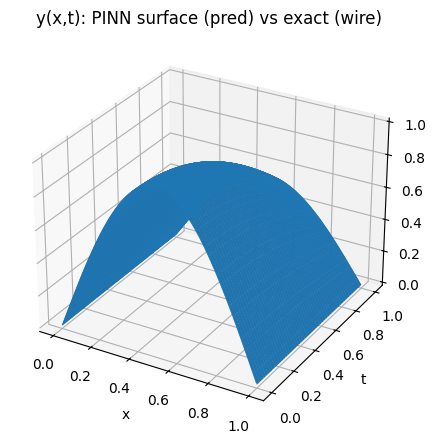

L2 grid error = 1.184e-05
L_inf grid error = 3.117e-05


In [ ]:
# @title Monodomain PINN baseline, configuration 1
# Purpose: Train the monodomain PINN baseline for comparison with configuration 1 OSPINN.

import torch, torch.nn as nn, torch.optim as optim
import numpy as np
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time

torch.manual_seed(1234); np.random.seed(1234)
torch.set_default_dtype(torch.float32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

def _now():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.perf_counter()

def _fmt_time(sec):
    m, s = divmod(int(sec), 60)
    h, m = divmod(m, 60)
    return f"{h:d}:{m:02d}:{s:02d}"

L = 1.0
Tmin, Tmax = 0.0, 1.0

pi = math.pi
def y_exact(x,t):
    return torch.sin(pi*x) * torch.cos(t)

def f_rhs(x,t):
    return (pi**4 - 1.0) * torch.sin(pi*x) * torch.cos(t)

def sample_xt(xa, xb, ta, tb, N):
    x = xa + (xb - xa) * torch.rand(N,1, device=device)
    t = ta + (tb - ta) * torch.rand(N,1, device=device)
    return torch.cat([x,t], 1)

def make_grad(xt):
    return xt.detach().clone().requires_grad_(True)

class Tiny1D(nn.Module):
    """maps t -> scalar; used for C_hat(t)"""
    def __init__(self, width=74, depth=4):
        super().__init__()
        layers = [nn.Linear(1, width), nn.Tanh()]
        for _ in range(depth-1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, t):
        return self.net(t)

class Tiny2D(nn.Module):
    """maps (x,t) -> scalar; used for F(x,t)"""
    def __init__(self, width=140, depth=5):
        super().__init__()
        self.act = nn.Tanh()
        self.inp = nn.Linear(2, width)
        self.hid = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.out = nn.Linear(width, 1)
        self.reset()
    def reset(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=nn.init.calculate_gain('tanh'))
                nn.init.zeros_(m.bias)
    def forward(self, xt):
        z = self.act(self.inp(xt))
        for lin in self.hid:
            z = self.act(lin(z))
        return self.out(z)

class YModel(nn.Module):
    """
    y(x,t) = sin(pi x) * C(t) + (x^3 (1-x)^3) * t^2 * F(x,t),
    with C(t) = 1 + t^2 * C_hat(t).
    This enforces:
      - y=0 and y_xx=0 at x∈{0,1} for all t (both terms satisfy it),
      - y(x,0)=sin(pi x) and y_t(x,0)=0 (by the t^2 factors).
    """
    def __init__(self):
        super().__init__()

        self.C_hat = Tiny1D(width=16, depth=8)
        self.F     = Tiny2D(width=50, depth=5)

    def forward(self, xt):
        x = xt[:,0:1]
        t = xt[:,1:2]
        C = 1.0 + (t**2)*self.C_hat(t)
        Sx3 = (x**3)*((1.0 - x)**3)
        y = torch.sin(pi*x)*C + Sx3*(t**2)*self.F(xt)
        return y

Y = YModel().to(device)

def grad(outputs, inputs):
    return torch.autograd.grad(outputs, inputs,
                               grad_outputs=torch.ones_like(outputs),
                               create_graph=True, retain_graph=True)[0]

def y_derivatives(Y_model, xt):
    """Return y_t, y_tt, y_x, y_xx, y_xxx, y_xxxx, y"""
    xt.requires_grad_(True)
    y = Y_model(xt)

    g = grad(y, xt)
    y_x  = g[:,0:1]
    y_t  = g[:,1:2]

    g2x  = grad(y_x, xt)
    y_xx = g2x[:,0:1]

    g3x  = grad(y_xx, xt)
    y_xxx = g3x[:,0:1]

    g4x  = grad(y_xxx, xt)
    y_xxxx = g4x[:,0:1]

    gt   = grad(y_t, xt)
    y_tt = gt[:,1:2]

    return y_t, y_tt, y_x, y_xx, y_xxx, y_xxxx, y

N_int = 300
xt_int = sample_xt(0.0, L, Tmin, Tmax, N_int)

p_exp = 2
def loss_pde():
    xtg = make_grad(xt_int)
    _, y_tt, _, _, _, y_xxxx, y = y_derivatives(Y, xtg)
    f = f_rhs(xtg[:,0:1], xtg[:,1:2])
    res = y_tt + y_xxxx - f
    Lpde = (res.abs()**p_exp).mean()
    return Lpde

optA = optim.Adam(Y.parameters(), lr=1e-3)
E_ADAM = 32600
best, best_state = float('inf'), None

t_total0 = _now()

t_adam0 = _now()
for it in range(1, E_ADAM+1):
    optA.zero_grad()
    L = loss_pde()
    L.backward()
    optA.step()
    Li = L.item()
    if Li < best:
        best, best_state = Li, {k: v.detach().clone() for k,v in Y.state_dict().items()}
    if it % 250 == 0:
        print(f"[Adam {it:5d}] PDE loss = {Li:.3e}")
t_adam = _now() - t_adam0
print(f"[Timing] Adam: {t_adam:.3f} s  ({t_adam/E_ADAM:.6f} s/step, {_fmt_time(t_adam)})")

if best_state is not None:
    Y.load_state_dict(best_state)

LBFGS_EPOCHS = 1050
LBFGS_ITERS  = 20

best_lbfgs = float('inf')
best_lbfgs_state = {k: v.detach().clone() for k,v in Y.state_dict().items()}

t_lbfgs0 = _now()
total_closures = 0
for e in range(1, LBFGS_EPOCHS + 1):
    optB = optim.LBFGS(
        Y.parameters(),
        lr=1.0,
        max_iter=LBFGS_ITERS,
        history_size=100,
        line_search_fn='strong_wolfe'
    )

    calls = [0]
    def closure():
        calls[0] += 1
        optB.zero_grad()
        L = loss_pde()
        L.backward()
        return L

    final_loss = optB.step(closure)
    total_closures += calls[0]

    cur_loss = float(loss_pde().detach())
    if cur_loss < best_lbfgs:
        best_lbfgs = cur_loss
        best_lbfgs_state = {k: v.detach().clone() for k,v in Y.state_dict().items()}

    if (e <= 250) or (e % 250 == 0) or (e == LBFGS_EPOCHS):
        print(f"[LBFGS epoch {e:4d}/{LBFGS_EPOCHS}] loss={cur_loss:.3e} "
              f"(step()->{float(final_loss):.3e}, closure_calls={calls[0]})")

t_lbfgs = _now() - t_lbfgs0
print(f"[Timing] LBFGS: {t_lbfgs:.3f} s  ({t_lbfgs/LBFGS_EPOCHS:.6f} s/epoch, {_fmt_time(t_lbfgs)}; total_closures={total_closures})")

Y.load_state_dict(best_lbfgs_state)
Y.eval()

t_total = _now() - t_total0
print(f"[Timing] Total training: {t_total:.3f} s  ({_fmt_time(t_total)})")
print("Training done.")

Nx, Nt = 1000, 1000
xg = torch.linspace(0.0, 1.0, Nx, device=device)
tg = torch.linspace(0.0, 1.0, Nt, device=device)
X, T = torch.meshgrid(xg, tg, indexing='ij')

with torch.no_grad():
    xt_grid = torch.stack([X.reshape(-1), T.reshape(-1)], dim=1)
    Yp = Y(xt_grid).reshape(Nx, Nt)
    Ye = torch.sin(pi*X) * torch.cos(T)

Xn, Tn = X.cpu().numpy(), T.cpu().numpy()
Ypn, Yen = Yp.cpu().numpy(), Ye.cpu().numpy()

fig = plt.figure(figsize=(7,4.5))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(Xn, Tn, Ypn, alpha=0.92, linewidth=0, antialiased=True)
ax.plot_wireframe(Xn[::6,::6], Tn[::6,::6], Yen[::6,::6],
                  rstride=1, cstride=1, linewidth=0.6, alpha=0.85)

ax.set_xlabel('x'); ax.set_ylabel('t'); ax.set_zlabel('y')
ax.set_title('y(x,t): PINN surface (pred) vs exact (wire)')
ax.view_init(elev=28, azim=-60)
plt.tight_layout(); plt.show()

L2 = float(np.sqrt(np.mean((Ypn - Yen)**2)))
print(f"L2 grid error = {L2:.3e}")
Linf = float(np.max(np.abs(Ypn - Yen)))
print(f"L_inf grid error = {Linf:.3e}")


## OSPINN: Configuration 2

This cell repeats the optimized Schwarz PINN experiment for the second configuration.


In [ ]:
# @title OSPINN training, configuration 2
# Purpose: Train the optimized Schwarz PINN model for configuration 2.

import torch, torch.nn as nn, torch.optim as optim
import copy, numpy as np, matplotlib.pyplot as plt, os, math
from math import pi
from concurrent.futures import ThreadPoolExecutor
import time

torch.manual_seed(1234); np.random.seed(1234)
torch.set_default_dtype(torch.float32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device :", device)

def _now():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.perf_counter()

os.makedirs("checkpoints", exist_ok=True)
best_ckpt = {
    "metric": float("inf"),
    "it": 0,
    "z1": None,
    "z2": None,
}
def _is_finite(x): return (x is not None) and (not math.isnan(x)) and (not math.isinf(x))
def _save(sd, path): torch.save(sd, path)

L, delta = 1.0, 0.3
Tmin, Tmax = 0.0, 1.0
dt  = 0.01
Nt  = int((Tmax - Tmin) / dt)
max_iter = 35
tol      = 1e-5
l2eps    = 1e-5
WARM_START = True

def u_exact(x,t): return -pi**2 * torch.sin(pi*x) * torch.cos(t)
def v_exact(x,t): return -           torch.sin(pi*x) * torch.sin(t)
def f_rhs (x,t): return (pi**4 - 1.0) * torch.sin(pi*x) * torch.cos(t)
def z_exact(x,t): return torch.cat([u_exact(x,t), v_exact(x,t)], 1)

def sample_xt(xa, xb, ta, tb, N):
    x = xa + (xb - xa) * torch.rand(N,1, device=device)
    t = ta + (tb - ta) * torch.rand(N,1, device=device)
    return torch.cat([x,t], 1)

def make_grad(z):
    return z.detach().clone().requires_grad_(True)

def deriv_all(out, xt):
    """Return [∂_t u, ∂_t v, ∂_x u, ∂_x v]."""
    u, v = out[:,0:1], out[:,1:2]
    gu = torch.autograd.grad(u, xt, torch.ones_like(u),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    gv = torch.autograd.grad(v, xt, torch.ones_like(v),
                             create_graph=True, retain_graph=True,
                             allow_unused=True)[0]
    if gu is None: gu = torch.zeros_like(xt)
    if gv is None: gv = torch.zeros_like(xt)
    return gu[:,1:2], gv[:,1:2], gu[:,0:1], gv[:,0:1]

def second_x(first_x, xt):
    g = torch.autograd.grad(first_x, xt, torch.ones_like(first_x),
                            create_graph=True, retain_graph=True,
                            allow_unused=True)[0]
    if g is None: g = torch.zeros_like(first_x)
    return g[:,0:1]

def build_complex_kernels(a, sign):
    ω   = 2*np.pi*np.fft.fftfreq(Nt, d=dt)
    eta = 1e-3/dt
    k   = np.sqrt(ω + 1j*eta)
    ka  = k * a

    s, c = np.sin(ka), np.cos(ka)
    s = np.where(np.abs(s)>1e-9, s, np.sign(np.real(s))*1e-9 + 0j)

    spec = sign * (k * c / s)

    spec[0] = sign * (1.0/a)
    K  = np.fft.ifft(spec) / dt
    Ka = K.real.astype(np.float32)
    Kb = K.imag.astype(np.float32)
    return torch.tensor(Ka, dtype=torch.float32, device=device), \
           torch.tensor(Kb, dtype=torch.float32, device=device)

def build_toeplitz(K):
    Nt_ = K.numel()
    W   = torch.zeros(Nt_, Nt_, device=device, dtype=K.dtype)
    for k in range(Nt_):
        W[k, :k+1] = K[:k+1].flip(0)
    return W * dt

Ka1, Kb1 = build_complex_kernels(L - delta, +1)
Ka2, Kb2 = build_complex_kernels(delta,     -1)
Wa1, Wb1 = build_toeplitz(Ka1), build_toeplitz(Kb1)
Wa2, Wb2 = build_toeplitz(Ka2), build_toeplitz(Kb2)

def interface_LHS_complex(net, xt_if_all, Wa, Wb):
    xtg  = make_grad(xt_if_all)
    out  = net(xtg)
    _, _, ux, vx = deriv_all(out, xtg)
    du   = torch.cat([ux, vx], 1)
    Ra   = (Wa @ out)
    Rb   = (Wb @ out)
    JRb  = torch.stack([-Rb[:,1], Rb[:,0]], dim=1)
    return du + Ra + JRb, out

def build_target_from_other_complex(net_other, xt_if_all, Wa, Wb):
    xtg  = xt_if_all.detach().clone().requires_grad_(True)
    out  = net_other(xtg)
    _, _, ux, vx = deriv_all(out, xtg)
    du   = torch.cat([ux, vx], 1)
    Ra   = (Wa @ out)
    Rb   = (Wb @ out)
    JRb  = torch.stack([-Rb[:,1], Rb[:,0]], dim=1)
    return (du + Ra + JRb).detach()

class Net(nn.Module):
    def __init__(self, depth=6, width=47):
        super().__init__()
        self.act = nn.Tanh()
        self.inp = nn.Linear(2, width)
        self.hid = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.out = nn.Linear(width, 2)

    def forward(self, xt):
        z = self.act(self.inp(xt))
        for lin in self.hid:
            z = self.act(lin(z))
        h = self.out(z)

        x = xt[:, 0:1]
        t = xt[:, 1:2]
        Sx = x * (1.0 - x)

        u0 = -pi**2 * torch.sin(pi * x)
        v0 = torch.zeros_like(x)

        u_hat = h[:, 0:1]
        v_hat = h[:, 1:2]

        u = u0 + Sx * t * u_hat
        v = v0 + Sx * t * v_hat

        return torch.cat([u, v], dim=1)

def init_xavier(m):
    for l in m.modules():
        if isinstance(l, nn.Linear):
            nn.init.xavier_uniform_(l.weight, gain=nn.init.calculate_gain('tanh'))
            l.bias.data.zero_()

def new_model(seed):
    torch.manual_seed(seed)
    net = Net().to(device)
    init_xavier(net)
    return net

w_pde  = 1.0
w_if   = 1.0
p_exp  = 2

Ni_int1, Ni_int2 = 400,400
xt_int1 = sample_xt(0,       delta, Tmin, Tmax, Ni_int1)
xt_int2 = sample_xt(delta,   L,     Tmin, Tmax, Ni_int2)

t_all     = torch.arange(Nt, device=device).unsqueeze(1) * dt
x_if_all  = torch.full((Nt,1), delta, device=device)
xt_if_all = torch.cat([x_if_all, t_all], 1)

z1, z2 = new_model(1), new_model(2)

def l2_errors_uv(z1, z2, delta, Nx=1000):
    x = torch.linspace(0.0, 1.0, Nx, device=device)
    t = (Tmin + torch.arange(Nt, device=device) * dt).clamp(max=Tmin + (Nt-1)*dt)
    X, Tm = torch.meshgrid(x, t, indexing='ij')

    with torch.no_grad():
        XT   = torch.stack([X.reshape(-1), Tm.reshape(-1)], dim=1)
        out1 = z1(XT)
        out2 = z2(XT)
        Z    = torch.where((XT[:, 0:1] <= delta).expand_as(out1), out1, out2)

        U = Z[:, 0].reshape(Nx, Nt)
        V = Z[:, 1].reshape(Nx, Nt)

        Ue = u_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(U.dtype)
        Ve = v_exact(X.reshape(-1, 1), Tm.reshape(-1, 1)).reshape(Nx, Nt).to(V.dtype)

        L2_u = torch.mean((U - Ue) ** 2).sqrt().item()
        L2_v = torch.mean((V - Ve) ** 2).sqrt().item()

    return L2_u, L2_v

@torch.no_grad()
def interface_gap_L2_time(z1, z2, delta, Nt, dt, device):
    t = torch.arange(Nt, device=device, dtype=torch.float32).unsqueeze(1) * dt
    x = torch.full((Nt, 1), float(delta), device=device, dtype=torch.float32)
    xt = torch.cat([x, t], 1)
    diff = z1(xt) - z2(xt)
    per_t = torch.linalg.norm(diff, dim=1)
    return float(torch.sqrt(torch.sum(per_t**2) * dt))

@torch.no_grad()
def plot_piecewise_at_t(
    z1_model: torch.nn.Module,
    z2_model: torch.nn.Module,
    t_value: float,
    delta: float,
    L: float = 1.0,
    n1: int = 400,
    n2: int = 400,
    comp: int = 0,
    save_path: str | None = None,
    show_gap: bool = True,
    show_fig: bool = False,
):
    """
    Plot z1 on [0,delta) and z2 on [delta,L] at fixed time t_value.
    If model output has 2 columns, 'comp' selects the component (0=u, 1=v).
    Returns a dict with the pointwise interface gap at x=delta.
    """

    def _first_param_device_dtype(m):
        p = next(m.parameters(), None)
        return (p.device, p.dtype) if p is not None else (torch.device('cpu'), torch.float32)

    dev1, dt1 = _first_param_device_dtype(z1_model)
    dev2, dt2 = _first_param_device_dtype(z2_model)
    use_dev = dev1 if dev1.type != 'cpu' else dev2
    use_dt  = dt1

    x1 = torch.linspace(0.0, float(delta), steps=max(n1, 2), device=use_dev, dtype=use_dt)
    if x1.numel() > 1: x1 = x1[:-1]
    x2 = torch.linspace(float(delta), float(L), steps=max(n2, 2), device=use_dev, dtype=use_dt)

    t1 = torch.full_like(x1, float(t_value))
    t2 = torch.full_like(x2, float(t_value))
    xt1 = torch.stack([x1, t1], dim=1)
    xt2 = torch.stack([x2, t2], dim=1)

    z1_model.eval(); z2_model.eval()
    y1 = z1_model(xt1)
    y2 = z2_model(xt2)

    def _pick_column(Y):
        if Y.ndim == 1:        return Y
        if Y.shape[1] == 1:    return Y[:, 0]
        if Y.shape[1] >= 2:    return Y[:, comp]
        raise ValueError("Unsupported model output shape.")

    y1c = _pick_column(y1)
    y2c = _pick_column(y2)

    gap_info = None
    if show_gap:
        xt_delta = torch.tensor([[float(delta), float(t_value)]], device=use_dev, dtype=use_dt)
        y1d = _pick_column(z1_model(xt_delta)).item()
        y2d = _pick_column(z2_model(xt_delta)).item()
        gap_info = dict(x=float(delta), z1=y1d, z2=y2d, gap=y1d - y2d)

    x1_np, y1_np = x1.detach().cpu().numpy(), y1c.detach().cpu().numpy()
    x2_np, y2_np = x2.detach().cpu().numpy(), y2c.detach().cpu().numpy()

    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    ax.plot(x1_np, y1_np, linewidth=1.8, label=r"$z_1(x,t_\star)$ on $[0,\delta)$")
    ax.plot(x2_np, y2_np, linewidth=1.8, label=r"$z_2(x,t_\star)$ on $[\delta,L]$")
    ax.axvline(float(delta), linestyle="--", linewidth=1.0)

    if show_gap and gap_info is not None:
        ax.scatter([gap_info["x"]], [gap_info["z1"]], s=30, zorder=3, label=r"$z_1(\delta,t_\star)$")
        ax.scatter([gap_info["x"]], [gap_info["z2"]], s=30, zorder=3, label=r"$z_2(\delta,t_\star)$")

    ax.set_xlabel("x"); ax.set_ylabel(f"component {comp}")
    ax.set_xlim(0.0, float(L)); ax.grid(True, linewidth=0.4, alpha=0.4)
    ttl_gap = "" if gap_info is None else f", gap={gap_info['gap']:.2e}"
    ax.set_title(fr"Piecewise at $t_\star={t_value}$ (comp={comp}), $\delta={delta}$" + ttl_gap)
    ax.legend(loc="best", fontsize=9, frameon=True)
    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=160)
    if show_fig:
        plt.show()
    plt.close(fig)

    return gap_info
def after_iter_plot(
    it: int,
    z1_model: torch.nn.Module,
    z2_model: torch.nn.Module,
    t_value: float,
    delta: float,
    outdir: str = "content/mnt/iter_plots",
    L: float = 1.0
):
    """
    Save two figures per iteration (u and v) at time t_value.
    Returns the gaps at x=delta for u and v.
    """
    os.makedirs(outdir, exist_ok=True)
    p_u = os.path.join(outdir, f"u_iter{it:03d}.png")
    p_v = os.path.join(outdir, f"v_iter{it:03d}.png")

    g_u = plot_piecewise_at_t(z1_model, z2_model, t_value, delta, L=L, comp=0, save_path=p_u, show_gap=True)
    g_v = plot_piecewise_at_t(z1_model, z2_model, t_value, delta, L=L, comp=1, save_path=p_v, show_gap=True)
    return {"gap_u": (None if g_u is None else g_u["gap"]),
            "gap_v": (None if g_v is None else g_v["gap"])}

def warm_start(net, domain='left', steps=300, lr=1e-3):
    opt = optim.Adam(net.parameters(), lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        xtg  = make_grad(xt_int1 if domain == 'left' else xt_int2)
        outg = net(xtg)
        u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
        lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
        loss = w_pde * lpde
        loss.backward(); opt.step()

def fit_Omega1(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int1)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
            lhs, _ = interface_LHS_complex(net, xt_if_all, Wa1, Wb1)
            lif = (lhs - target_full).abs().pow(p_exp).mean()
            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss
        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

def fit_Omega2(net, opt, epochs, target_full):
    best, best_st = float('inf'), None
    for _ in range(epochs):
        def closure():
            opt.zero_grad()
            xtg  = make_grad(xt_int2)
            outg = net(xtg)
            u_t, v_t, u_x, v_x = deriv_all(outg, xtg)
            lpde = ((u_t - second_x(v_x, xtg)).abs()**p_exp +
                    (v_t + second_x(u_x, xtg) - f_rhs(xtg[:,0:1], xtg[:,1:2])).abs()**p_exp).mean()
            lhs, _ = interface_LHS_complex(net, xt_if_all, Wa2, Wb2)
            lif = (lhs - target_full).abs().pow(p_exp).mean()
            loss = w_pde*lpde + w_if*lif
            loss.backward()
            return loss
        loss = opt.step(closure) if isinstance(opt, optim.LBFGS) else (closure(), opt.step())[0]
        if loss.item() < best:
            best, best_st = loss.item(), copy.deepcopy(net.state_dict())
    net.load_state_dict(best_st)
    return net

def interface_metrics_complex(z1, z2, xt_if_all, Wa1, Wb1, Wa2, Wb2):
    xtg = xt_if_all.detach().clone().requires_grad_(True)
    out1, out2 = z1(xtg), z2(xtg)

    _,_,ux1,vx1 = deriv_all(out1, xtg); du1 = torch.cat([ux1, vx1], 1)
    _,_,ux2,vx2 = deriv_all(out2, xtg); du2 = torch.cat([ux2, vx2], 1)

    Ra1_1 = Wa1 @ out1; Rb1_1 = Wb1 @ out1; JRb1_1 = torch.stack([-Rb1_1[:,1], Rb1_1[:,0]], 1)
    Ra1_2 = Wa1 @ out2; Rb1_2 = Wb1 @ out2; JRb1_2 = torch.stack([-Rb1_2[:,1], Rb1_2[:,0]], 1)
    L1_z1 = du1 + Ra1_1 + JRb1_1
    L1_z2 = du2 + Ra1_2 + JRb1_2

    Ra2_2 = Wa2 @ out2; Rb2_2 = Wb2 @ out2; JRb2_2 = torch.stack([-Rb2_2[:,1], Rb2_2[:,0]], 1)
    Ra2_1 = Wa2 @ out1; Rb2_1 = Wb2 @ out1; JRb2_1 = torch.stack([-Rb2_1[:,1], Rb2_1[:,0]], 1)
    L2_z2 = du2 + Ra2_2 + JRb2_2
    L2_z1 = du1 + Ra2_1 + JRb2_1

    r1 = torch.sqrt(((L1_z1 - L1_z2)**2).mean()).item()
    r2 = torch.sqrt(((L2_z2 - L2_z1)**2).mean()).item()
    return r1, r2

t_decomp_total0 = _now()
t_warm = 0.0
iter_times = []

if WARM_START:
    t0 = _now()
    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(warm_start, z1, xt_int1, 300, 1e-3)
        f2 = pool.submit(warm_start, z2, xt_int2, 300, 1e-3)
        f1.result(); f2.result()
    t_warm = _now() - t0
    print(f"[Timing] Warm-start total (parallel): {t_warm:.3f} s")

for it in range(1, max_iter+1):
    t_it0 = _now()
    print(f"\n=== Schwarz iteration {it} (global in time, parallel Jacobi) ===")

    target_R1_full = build_target_from_other_complex(z2, xt_if_all, Wa1, Wb1)
    target_R2_full = build_target_from_other_complex(z1, xt_if_all, Wa2, Wb2)

    def _train_O1():
        fit_Omega1(z1, optim.Adam(z1.parameters(), lr=1e-3), 100, target_R1_full)
        z1.eval()
        fit_Omega1(z1, optim.LBFGS(z1.parameters(), lr=1, max_iter=20), 15, target_R1_full)
        return True
    def _train_O2():
        fit_Omega2(z2, optim.Adam(z2.parameters(), lr=1e-3), 100, target_R2_full)
        z2.eval()
        fit_Omega2(z2, optim.LBFGS(z2.parameters(), lr=1, max_iter=20), 15, target_R2_full)
        return True

    with ThreadPoolExecutor(max_workers=2) as pool:
        f1 = pool.submit(_train_O1)
        f2 = pool.submit(_train_O2)
        f1.result(); f2.result()
    t_it = _now() - t_it0
    iter_times.append(t_it)
    print(f"[Timing] Schwarz iter {it} : {t_it:.3f} s")

    r1, r2 = interface_metrics_complex(z1, z2, xt_if_all, Wa1, Wb1, Wa2, Wb2)
    res = max(r1, r2)
    print(f"r1={r1:.3e}  r2={r2:.3e}  (max={res:.3e})")

    L2u, L2v = l2_errors_uv(z1, z2, delta, Nx=100)
    print(f"[iter {it}] L2(u)={L2u:.3e}  L2(v)={L2v:.3e}")
    diffz = interface_gap_L2_time(z1, z2, delta, Nt, dt, device)
    print(f"[iter {it}] z1(δ,⋅)−z2(δ,⋅)(t)={diffz:.3e}")
    after_iter_plot(it, z1, z2, t_value=0.2, delta=delta, outdir="content/mnt/iter_plots", L=L)

    if max(L2u, L2v) <= l2eps or diffz <= tol:
        print("Converged (global-in-time) by tolerance.")
        break

t_decomp_total = _now() - t_decomp_total0
if iter_times:
    avg_it = sum(iter_times) / len(iter_times)
    print(f"\n[Timing] Decomposed (z1/z2) total: {t_decomp_total:.3f} s "
          f"(warm-start {t_warm:.3f} s, Schwarz {t_decomp_total - t_warm:.3f} s)")
    print(f"[Timing] Schwarz per-iter: avg {avg_it:.3f} s, "
          f"min {min(iter_times):.3f} s, max {max(iter_times):.3f} s")

print("\nFinished global-in-time Schwarz with complex DtN (Example 3).")
_save(z1.state_dict(), "checkpoints/final_last_z1.pt")
_save(z2.state_dict(), "checkpoints/final_last_z2.pt")
print("Saved final (last-iteration) models to checkpoints/final_last_*.pt")


Device : cpu
[Timing] Warm-start total (parallel): 14.075 s

=== Schwarz iteration 1 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 1 : 25.247 s
r1=2.758e+00  r2=3.897e+00  (max=3.897e+00)
[iter 1] L2(u)=4.857e-01  L2(v)=1.789e-01
[iter 1] z1(δ,⋅)−z2(δ,⋅)(t)=2.635e-01

=== Schwarz iteration 2 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 2 : 25.177 s
r1=3.227e+00  r2=1.421e+00  (max=3.227e+00)
[iter 2] L2(u)=1.942e-01  L2(v)=3.151e-01
[iter 2] z1(δ,⋅)−z2(δ,⋅)(t)=3.640e-01

=== Schwarz iteration 3 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 3 : 25.276 s
r1=1.186e+00  r2=1.654e+00  (max=1.654e+00)
[iter 3] L2(u)=6.809e-02  L2(v)=2.351e-01
[iter 3] z1(δ,⋅)−z2(δ,⋅)(t)=9.868e-02

=== Schwarz iteration 4 (global in time, parallel Jacobi) ===
[Timing] Schwarz iter 4 : 25.489 s
r1=1.401e+00  r2=6.007e-01  (max=1.401e+00)
[iter 4] L2(u)=9.308e-02  L2(v)=1.427e-01
[iter 4] z1(δ,⋅)−z2(δ,⋅)(t)=1.473e-01

=== Schwarz iteration 5 (global in time, parallel J

## Displacement Reconstruction After Configuration 2

This cell reconstructs the displacement `y` using the OSPINN outputs from configuration 2.


In [ ]:
# @title Displacement reconstruction, configuration 2
# Purpose: Train a displacement model Y using the configuration 2 OSPINN fields.

import time
BEST_Z1_CKPT = "checkpoints/final_last_z1.pt"
BEST_Z2_CKPT = "checkpoints/final_last_z2.pt"
BEST_Y_CKPT  = "/content/Y_pinn_best.pt"

def y_exact(x, t):
    return torch.sin(pi * x) * torch.cos(t)

class Net(nn.Module):
    def __init__(self, depth=6, width=47):
        super().__init__()
        self.act = nn.Tanh()
        self.inp = nn.Linear(2, width)
        self.hid = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.out = nn.Linear(width, 2)
    def forward(self, xt):
        z = self.act(self.inp(xt))
        for lin in self.hid:
            z = self.act(lin(z))
        h = self.out(z)
        x = xt[:,0:1]; t = xt[:,1:2]
        Sx = x*(1.0 - x)
        u0 = -pi**2 * torch.sin(pi * x)
        v0 = torch.zeros_like(x)
        u = u0 + Sx * t * h[:,0:1]
        v = v0 + Sx * t * h[:,1:2]
        return torch.cat([u,v], dim=1)

z1 = Net().to(device)
z2 = Net().to(device)
z1.load_state_dict(torch.load(BEST_Z1_CKPT, map_location=device))
z2.load_state_dict(torch.load(BEST_Z2_CKPT, map_location=device))
z1.eval(); z2.eval()
print("Loaded best z1/z2 from checkpoints.")
L2u, L2v = l2_errors_uv(z1, z2, delta, Nx=100)
print(f"[z1/z2 checkpoints] L2(u)={L2u:.3e}  L2(v)={L2v:.3e}")

def y_exact(x, t):
    return torch.sin(pi * x) * torch.cos(t)

@torch.no_grad()
def uv_from_subdomains(xt: torch.Tensor) -> torch.Tensor:
    """
    xt: [N,2] with cols (x,t). Returns [N,2] = [u,v],
    using z1 on x<=delta and z2 on x>delta.
    """
    z1.eval(); z2.eval()
    out1 = z1(xt)
    out2 = z2(xt)
    mask = (xt[:, 0:1] <= delta).expand_as(out1)
    return torch.where(mask, out1, out2)

class Tiny1D(nn.Module):
    """C_hat(t)"""
    def __init__(self, width=24, depth=5):
        super().__init__()
        layers = [nn.Linear(1, width), nn.Tanh()]
        for _ in range(depth-1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, t):
        return self.net(t)

class Tiny2D(nn.Module):
    """F(x,t)"""
    def __init__(self, width=48, depth=4):
        super().__init__()
        self.act = nn.Tanh()
        self.inp = nn.Linear(2, width)
        self.hid = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.out = nn.Linear(width, 1)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=nn.init.calculate_gain('tanh'))
                nn.init.zeros_(m.bias)
    def forward(self, xt):
        z = self.act(self.inp(xt))
        for lin in self.hid:
            z = self.act(lin(z))
        return self.out(z)

class YModel(nn.Module):
    """
    HARD BC/IC ansatz:
      y(x,t) = sin(pi x) * C(t) + [x^3 (1-x)^3] * t^2 * F(x,t),
      with C(t) = 1 + t^2 * C_hat(t).
    """
    def __init__(self):
        super().__init__()
        self.C_hat = Tiny1D(width=22, depth=8)
        self.F     = Tiny2D(width=45, depth=3)
    def forward(self, xt):
        x = xt[:, 0:1]
        t = xt[:, 1:2]
        C  = 1.0 + (t**2) * self.C_hat(t)
        Sx = (x**3) * ((1.0 - x)**3)
        y  = torch.sin(pi * x) * C + Sx * (t**2) * self.F(xt)
        return y

Y = YModel().to(device)

def y_t_and_y_xx(Y_net: nn.Module, xt: torch.Tensor):
    """
    xt must require_grad. Returns y_t, y_xx, y at those points.
    """
    y  = Y_net(xt)
    gy = torch.autograd.grad(y, xt, torch.ones_like(y),
                             create_graph=True, retain_graph=True)[0]
    y_t = gy[:, 1:2]
    y_x = gy[:, 0:1]
    g2  = torch.autograd.grad(y_x, xt, torch.ones_like(y_x),
                              create_graph=True, retain_graph=True)[0]
    y_xx = g2[:, 0:1]
    return y_t, y_xx, y

xt_train_Y = torch.cat(
    [xt_int1.detach(), xt_int2.detach(), xt_if_all.detach()], dim=0
).to(device)

xv = torch.linspace(0.0, 1.0, 100, device=device)
tv = torch.linspace(0.0, 1.0, 100, device=device)
Xv, Tv = torch.meshgrid(xv, tv, indexing="ij")
xt_val = torch.stack([Xv.reshape(-1), Tv.reshape(-1)], dim=1)

@torch.no_grad()
def L2_y_on_val(Y_net):
    y_pred = Y_net(xt_val)
    y_true = y_exact(xt_val[:,0:1], xt_val[:,1:2])
    e = y_pred - y_true
    return float(torch.max(torch.abs(e)))

p_exp = 2
w_u, w_v = 1.0, 1.0

def make_grad_copy(xt: torch.Tensor):
    return xt.detach().clone().requires_grad_(True)

def loss_components_Y():
    xtg = make_grad_copy(xt_train_Y)
    with torch.no_grad():
        uv   = uv_from_subdomains(xt_train_Y)
        u_tr = uv[:, 0:1]
        v_tr = uv[:, 1:2]
    y_t, y_xx, _ = y_t_and_y_xx(Y, xtg)
    L_u = (y_xx - u_tr).abs().pow(p_exp).mean()
    L_v = (y_t  - v_tr).abs().pow(p_exp).mean()
    loss = w_u * L_u + w_v * L_v
    return loss, (L_u.item(), L_v.item())

def _now():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.perf_counter()

def _fmt_time(sec):
    m, s = divmod(int(sec), 60)
    h, m = divmod(m, 60)
    return f"{h:d}:{m:02d}:{s:02d}"
optA   = optim.Adam(Y.parameters(), lr=1e-3)
E_ADAM = 25000

best_loss = float('inf')
best_val  = float('inf')
best_st   = None
t_total0 = _now()

t_adam0 = _now()
for it in range(1, E_ADAM+1):
    optA.zero_grad()
    loss, (Lu, Lv) = loss_components_Y()
    loss.backward()
    optA.step()

    if loss.item() < best_loss:
        best_loss = loss.item()

    if it % 200 == 0 or it == 1:
        L2_val = L2_y_on_val(Y)
        if L2_val < best_val:
            best_val = L2_val
            best_st  = {k: v.detach().clone() for k, v in Y.state_dict().items()}
        t_adam = _now() - t_adam0
        print(f"[Y-Adam {it:5d}] loss={loss.item():.3e} | Lu={Lu:.2e} Lv={Lv:.2e} | L2_val(y)={L2_val:.3e}")

if best_st is not None:
    Y.load_state_dict(best_st)
    print(f"Best validation L2(y) = {best_val:.3e}")
t_total = _now() - t_total0
print(f"[Timing] Total Y training: {t_total:.3f} s  ({_fmt_time(t_total)})")

torch.save(Y.state_dict(), BEST_Y_CKPT)
print(f"Saved best Y-PINN (Adam only, best on validation) to: {BEST_Y_CKPT}")

Y.eval()
print("Y-PINN trained on interior + interface samples (Adam only, N=", xt_train_Y.shape[0], ").")

@torch.no_grad()
def errors_y_on_grid(
    Y_net: nn.Module,
    Nx: int = 1000,
    Nt: int = 1000,
    x_min: float = 0.0,
    x_max: float = 1.0,
    t_min: float = 0.0,
    t_max: float = 1.0,
):
    xg = torch.linspace(x_min, x_max, Nx, device=device, dtype=torch.float32)
    tg = torch.linspace(t_min, t_max, Nt, device=device, dtype=torch.float32)
    X, T = torch.meshgrid(xg, tg, indexing="ij")
    XT = torch.stack([X.reshape(-1), T.reshape(-1)], dim=1)

    y_pred = Y_net(XT)
    y_true = y_exact(XT[:, 0:1], XT[:, 1:2])
    e = y_pred - y_true

    L2   = float(torch.sqrt(torch.mean(e**2)))
    Linf = float(torch.max(torch.abs(e)))
    return L2, Linf

L2y_g, Linfy_g = errors_y_on_grid(Y, Nx=1000, Nt=1000)
print(f"[Y @ 1000x1000 grid] N={1000*1000}  L2(y)={L2y_g:.3e}  Linf(y)={Linfy_g:.3e}")

@torch.no_grad()
def print_slice_Y(t_star=0.20, xs=(0.1,0.2,0.3,0.4,0.5)):
    XT = torch.tensor([[x, t_star] for x in xs], device=device, dtype=torch.float32)
    y_p = Y(XT).squeeze(1)
    y_e = y_exact(XT[:,0:1], XT[:,1:2]).squeeze(1)
    print(f"\n[Y slice at t={t_star:.2f}]")
    for xq, yp, ye in zip(xs, y_p.tolist(), y_e.tolist()):
        print(f"x={xq:.2f}:  exact={ye: .6e}  Y={yp: .6e}  err={yp-ye: .2e}")

print_slice_Y(0.20)


Loaded best z1/z2 from checkpoints.
[z1/z2 checkpoints] L2(u)=1.797e-04  L2(v)=1.890e-04
[Y-Adam     1] loss=2.822e+00 | Lu=2.65e+00 Lv=1.69e-01 | L2_val(y)=5.016e-01
[Y-Adam   200] loss=9.617e-04 | Lu=5.94e-04 Lv=3.67e-04 | L2_val(y)=8.634e-03
[Y-Adam   400] loss=1.577e-04 | Lu=1.01e-04 Lv=5.63e-05 | L2_val(y)=3.184e-03
[Y-Adam   600] loss=5.286e-06 | Lu=5.01e-06 Lv=2.80e-07 | L2_val(y)=2.340e-04
[Y-Adam   800] loss=3.441e-06 | Lu=3.23e-06 Lv=2.15e-07 | L2_val(y)=2.059e-04
[Y-Adam  1000] loss=2.648e-06 | Lu=2.47e-06 Lv=1.76e-07 | L2_val(y)=1.777e-04
[Y-Adam  1200] loss=2.127e-06 | Lu=1.98e-06 Lv=1.46e-07 | L2_val(y)=1.553e-04
[Y-Adam  1400] loss=1.742e-06 | Lu=1.62e-06 Lv=1.22e-07 | L2_val(y)=1.385e-04
[Y-Adam  1600] loss=1.443e-06 | Lu=1.34e-06 Lv=1.02e-07 | L2_val(y)=1.256e-04
[Y-Adam  1800] loss=1.201e-06 | Lu=1.12e-06 Lv=8.51e-08 | L2_val(y)=1.154e-04
[Y-Adam  2000] loss=1.001e-06 | Lu=9.29e-07 Lv=7.15e-08 | L2_val(y)=1.072e-04
[Y-Adam  2200] loss=8.320e-07 | Lu=7.72e-07 Lv=6.02e-

## Monodomain PINN Baseline for Configuration 2

This cell reruns the monodomain PINN baseline for comparison with the second OSPINN configuration.


Device: cpu
[Adam   250] PDE loss = 1.215e-02
[Adam   500] PDE loss = 4.326e-03
[Adam   750] PDE loss = 3.185e-03
[Adam  1000] PDE loss = 2.715e-03
[Adam  1250] PDE loss = 2.386e-03
[Adam  1500] PDE loss = 2.128e-03
[Adam  1750] PDE loss = 1.912e-03
[Adam  2000] PDE loss = 1.722e-03
[Adam  2250] PDE loss = 1.680e-03
[Adam  2500] PDE loss = 1.448e-03
[Adam  2750] PDE loss = 4.060e-03
[Adam  3000] PDE loss = 1.148e-03
[Adam  3250] PDE loss = 1.973e-01
[Adam  3500] PDE loss = 8.833e-04
[Adam  3750] PDE loss = 7.575e-04
[Adam  4000] PDE loss = 6.666e-04
[Adam  4250] PDE loss = 5.313e-04
[Adam  4500] PDE loss = 4.815e-04
[Adam  4750] PDE loss = 3.653e-04
[Adam  5000] PDE loss = 4.545e-04
[Adam  5250] PDE loss = 2.545e-04
[Adam  5500] PDE loss = 1.871e-04
[Adam  5750] PDE loss = 1.412e-04
[Adam  6000] PDE loss = 1.621e-04
[Adam  6250] PDE loss = 1.100e-04
[Adam  6500] PDE loss = 1.204e-04
[Adam  6750] PDE loss = 8.117e-05
[Adam  7000] PDE loss = 9.100e-05
[Adam  7250] PDE loss = 6.106e-05
[A

/tmp/ipython-input-3130253618.py:220: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  f"(step()->{float(final_loss):.3e}, closure_calls={calls[0]})")


[LBFGS epoch    1/1050] loss=2.802e-07 (step()->2.803e-07, closure_calls=7)
[LBFGS epoch    2/1050] loss=2.802e-07 (step()->2.802e-07, closure_calls=4)
[LBFGS epoch    3/1050] loss=2.802e-07 (step()->2.802e-07, closure_calls=4)
[LBFGS epoch    4/1050] loss=2.802e-07 (step()->2.802e-07, closure_calls=4)
[LBFGS epoch    5/1050] loss=2.802e-07 (step()->2.802e-07, closure_calls=4)
[LBFGS epoch    6/1050] loss=2.802e-07 (step()->2.802e-07, closure_calls=4)
[LBFGS epoch    7/1050] loss=2.802e-07 (step()->2.802e-07, closure_calls=4)
[LBFGS epoch    8/1050] loss=2.802e-07 (step()->2.802e-07, closure_calls=4)
[LBFGS epoch    9/1050] loss=2.802e-07 (step()->2.802e-07, closure_calls=4)
[LBFGS epoch   10/1050] loss=2.802e-07 (step()->2.802e-07, closure_calls=4)
[LBFGS epoch   11/1050] loss=2.802e-07 (step()->2.802e-07, closure_calls=4)
[LBFGS epoch   12/1050] loss=2.802e-07 (step()->2.802e-07, closure_calls=4)
[LBFGS epoch   13/1050] loss=2.802e-07 (step()->2.802e-07, closure_calls=4)
[LBFGS epoch

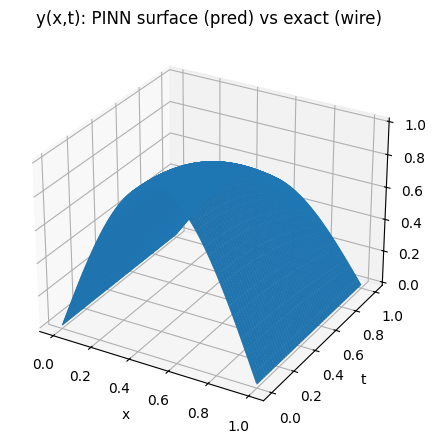

L2 grid error = 1.056e-05
L_inf grid error = 3.451e-05


In [ ]:
# @title Monodomain PINN baseline, configuration 2
# Purpose: Train the monodomain PINN baseline for comparison with configuration 2 OSPINN.

import torch, torch.nn as nn, torch.optim as optim
import numpy as np
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time

torch.manual_seed(1234); np.random.seed(1234)
torch.set_default_dtype(torch.float32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

def _now():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.perf_counter()

def _fmt_time(sec):
    m, s = divmod(int(sec), 60)
    h, m = divmod(m, 60)
    return f"{h:d}:{m:02d}:{s:02d}"

L = 1.0
Tmin, Tmax = 0.0, 1.0

pi = math.pi
def y_exact(x,t):
    return torch.sin(pi*x) * torch.cos(t)

def f_rhs(x,t):
    return (pi**4 - 1.0) * torch.sin(pi*x) * torch.cos(t)

def sample_xt(xa, xb, ta, tb, N):
    x = xa + (xb - xa) * torch.rand(N,1, device=device)
    t = ta + (tb - ta) * torch.rand(N,1, device=device)
    return torch.cat([x,t], 1)

def make_grad(xt):
    return xt.detach().clone().requires_grad_(True)

class Tiny1D(nn.Module):
    """maps t -> scalar; used for C_hat(t)"""
    def __init__(self, width=74, depth=4):
        super().__init__()
        layers = [nn.Linear(1, width), nn.Tanh()]
        for _ in range(depth-1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, t):
        return self.net(t)

class Tiny2D(nn.Module):
    """maps (x,t) -> scalar; used for F(x,t)"""
    def __init__(self, width=140, depth=5):
        super().__init__()
        self.act = nn.Tanh()
        self.inp = nn.Linear(2, width)
        self.hid = nn.ModuleList([nn.Linear(width, width) for _ in range(depth)])
        self.out = nn.Linear(width, 1)
        self.reset()
    def reset(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=nn.init.calculate_gain('tanh'))
                nn.init.zeros_(m.bias)
    def forward(self, xt):
        z = self.act(self.inp(xt))
        for lin in self.hid:
            z = self.act(lin(z))
        return self.out(z)

class YModel(nn.Module):
    """
    y(x,t) = sin(pi x) * C(t) + (x^3 (1-x)^3) * t^2 * F(x,t),
    with C(t) = 1 + t^2 * C_hat(t).
    This enforces:
      - y=0 and y_xx=0 at x∈{0,1} for all t (both terms satisfy it),
      - y(x,0)=sin(pi x) and y_t(x,0)=0 (by the t^2 factors).
    """
    def __init__(self):
        super().__init__()
        self.C_hat = Tiny1D(width=48, depth=3)
        self.F     = Tiny2D(width=80, depth=5)

    def forward(self, xt):
        x = xt[:,0:1]
        t = xt[:,1:2]
        C = 1.0 + (t**2)*self.C_hat(t)
        Sx3 = (x**3)*((1.0 - x)**3)
        y = torch.sin(pi*x)*C + Sx3*(t**2)*self.F(xt)
        return y

Y = YModel().to(device)

def grad(outputs, inputs):
    return torch.autograd.grad(outputs, inputs,
                               grad_outputs=torch.ones_like(outputs),
                               create_graph=True, retain_graph=True)[0]

def y_derivatives(Y_model, xt):
    """Return y_t, y_tt, y_x, y_xx, y_xxx, y_xxxx, y"""
    xt.requires_grad_(True)
    y = Y_model(xt)

    g = grad(y, xt)
    y_x  = g[:,0:1]
    y_t  = g[:,1:2]

    g2x  = grad(y_x, xt)
    y_xx = g2x[:,0:1]

    g3x  = grad(y_xx, xt)
    y_xxx = g3x[:,0:1]

    g4x  = grad(y_xxx, xt)
    y_xxxx = g4x[:,0:1]

    gt   = grad(y_t, xt)
    y_tt = gt[:,1:2]

    return y_t, y_tt, y_x, y_xx, y_xxx, y_xxxx, y

N_int = 900
xt_int = sample_xt(0.0, L, Tmin, Tmax, N_int)

p_exp = 2
def loss_pde():
    xtg = make_grad(xt_int)
    _, y_tt, _, _, _, y_xxxx, y = y_derivatives(Y, xtg)
    f = f_rhs(xtg[:,0:1], xtg[:,1:2])
    res = y_tt + y_xxxx - f
    Lpde = (res.abs()**p_exp).mean()
    return Lpde

optA = optim.Adam(Y.parameters(), lr=1e-3)
E_ADAM = 32600
best, best_state = float('inf'), None

t_total0 = _now()

t_adam0 = _now()
for it in range(1, E_ADAM+1):
    optA.zero_grad()
    L = loss_pde()
    L.backward()
    optA.step()
    Li = L.item()
    if Li < best:
        best, best_state = Li, {k: v.detach().clone() for k,v in Y.state_dict().items()}
    if it % 250 == 0:
        print(f"[Adam {it:5d}] PDE loss = {Li:.3e}")
t_adam = _now() - t_adam0
print(f"[Timing] Adam: {t_adam:.3f} s  ({t_adam/E_ADAM:.6f} s/step, {_fmt_time(t_adam)})")

if best_state is not None:
    Y.load_state_dict(best_state)

LBFGS_EPOCHS = 1050
LBFGS_ITERS  = 20

best_lbfgs = float('inf')
best_lbfgs_state = {k: v.detach().clone() for k,v in Y.state_dict().items()}

t_lbfgs0 = _now()
total_closures = 0
for e in range(1, LBFGS_EPOCHS + 1):
    optB = optim.LBFGS(
        Y.parameters(),
        lr=1.0,
        max_iter=LBFGS_ITERS,
        history_size=100,
        line_search_fn='strong_wolfe'
    )

    calls = [0]
    def closure():
        calls[0] += 1
        optB.zero_grad()
        L = loss_pde()
        L.backward()
        return L

    final_loss = optB.step(closure)
    total_closures += calls[0]

    cur_loss = float(loss_pde().detach())
    if cur_loss < best_lbfgs:
        best_lbfgs = cur_loss
        best_lbfgs_state = {k: v.detach().clone() for k,v in Y.state_dict().items()}

    if (e <= 250) or (e % 250 == 0) or (e == LBFGS_EPOCHS):
        print(f"[LBFGS epoch {e:4d}/{LBFGS_EPOCHS}] loss={cur_loss:.3e} "
              f"(step()->{float(final_loss):.3e}, closure_calls={calls[0]})")

t_lbfgs = _now() - t_lbfgs0
print(f"[Timing] LBFGS: {t_lbfgs:.3f} s  ({t_lbfgs/LBFGS_EPOCHS:.6f} s/epoch, {_fmt_time(t_lbfgs)}; total_closures={total_closures})")

Y.load_state_dict(best_lbfgs_state)
Y.eval()

t_total = _now() - t_total0
print(f"[Timing] Total training: {t_total:.3f} s  ({_fmt_time(t_total)})")
print("Training done.")

Nx, Nt = 1000, 1000
xg = torch.linspace(0.0, 1.0, Nx, device=device)
tg = torch.linspace(0.0, 1.0, Nt, device=device)
X, T = torch.meshgrid(xg, tg, indexing='ij')

with torch.no_grad():
    xt_grid = torch.stack([X.reshape(-1), T.reshape(-1)], dim=1)
    Yp = Y(xt_grid).reshape(Nx, Nt)
    Ye = torch.sin(pi*X) * torch.cos(T)

Xn, Tn = X.cpu().numpy(), T.cpu().numpy()
Ypn, Yen = Yp.cpu().numpy(), Ye.cpu().numpy()

fig = plt.figure(figsize=(7,4.5))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(Xn, Tn, Ypn, alpha=0.92, linewidth=0, antialiased=True)
ax.plot_wireframe(Xn[::6,::6], Tn[::6,::6], Yen[::6,::6],
                  rstride=1, cstride=1, linewidth=0.6, alpha=0.85)

ax.set_xlabel('x'); ax.set_ylabel('t'); ax.set_zlabel('y')
ax.set_title('y(x,t): PINN surface (pred) vs exact (wire)')
ax.view_init(elev=28, azim=-60)
plt.tight_layout(); plt.show()

L2 = float(np.sqrt(np.mean((Ypn - Yen)**2)))
print(f"L2 grid error = {L2:.3e}")
Linf = float(np.max(np.abs(Ypn - Yen)))
print(f"L_inf grid error = {Linf:.3e}")
